# 03 — Transit Search (BLS + TLS)
Runs both **Box Least Squares (BLS)** and **Transit Least Squares (TLS)** on all cleaned light curves.
TLS uses a physical transit shape — more sensitive than BLS for real planet signals.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
from tqdm import tqdm
import os, glob, warnings
warnings.filterwarnings('ignore')

# Install TLS if needed
try:
    from transitleastsquares import transitleastsquares, cleaned_array
    TLS_OK = True
    print('TLS ✅')
except ImportError:
    os.system('pip install transitleastsquares')
    try:
        from transitleastsquares import transitleastsquares, cleaned_array
        TLS_OK = True
        print('TLS installed ✅')
    except:
        TLS_OK = False
        print('TLS not available — using BLS only')

print('Imports OK!')

TLS installed ✅
Imports OK!


## 2. Configuration

In [ ]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [2]:
PROCESSED_DIR = '../data/processed/'
RESULTS_DIR   = '../outputs/'
PLOTS_DIR     = '../outputs/plots/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# Search parameters
MIN_PERIOD    = 1.0
MAX_PERIOD    = 13.0
MIN_DURATION  = 0.01
MAX_DURATION  = 0.3
SNR_THRESHOLD = 5.0

csv_files = glob.glob(os.path.join(PROCESSED_DIR, 'TIC_*.csv'))
print(f'Found {len(csv_files)} processed light curves')

Found 15 processed light curves


## 3. BLS Function (unchanged)

In [3]:
def run_bls(time, flux, min_period=1.0, max_period=13.0,
            min_duration=0.01, max_duration=0.3):
    mask = np.isfinite(flux)
    time, flux = time[mask], flux[mask]
    if len(time) < 100:
        return None
    max_dur_safe = min(max_duration, min_period * 0.8)
    durations    = np.linspace(min_duration, max_dur_safe, 20) * u.day
    bls          = BoxLeastSquares(time * u.day, flux)
    periodogram  = bls.autopower(
        durations,
        minimum_period  = min_period * u.day,
        maximum_period  = max_period * u.day,
        method='fast'
    )
    best_idx  = np.argmax(periodogram.power)
    stats     = bls.compute_stats(
        periodogram.period[best_idx],
        periodogram.duration[best_idx],
        periodogram.transit_time[best_idx]
    )
    depth     = float(stats['depth'][0])
    depth_err = float(stats['depth'][1])
    snr       = depth / depth_err if depth_err > 0 else 0.0
    return {
        'best_period'   : float(periodogram.period[best_idx].value),
        'best_duration' : float(periodogram.duration[best_idx].value),
        'best_depth'    : depth,
        'snr'           : snr,
        'bls_power'     : float(np.max(periodogram.power)),
        'transit_time'  : float(periodogram.transit_time[best_idx].value),
        'periodogram'   : periodogram
    }

print('BLS ready!')

BLS ready!


## 4. TLS Function (NEW)

In [4]:
def run_tls(time, flux, min_period=1.0, max_period=13.0):
    """
    Run Transit Least Squares (TLS) on a light curve.
    TLS uses a physical limb-darkened transit shape vs BLS box shape.
    Returns dict with period, depth, duration, SDE (signal detection efficiency),
    FAP, and transit times.
    """
    if not TLS_OK:
        return None

    # Clean array
    time_c, flux_c = cleaned_array(time, flux)
    if len(time_c) < 100:
        return None

    try:
        model  = transitleastsquares(time_c, flux_c)
        result = model.power(
            minimum_period   = min_period,
            maximum_period   = max_period,
            show_progress_bar= False
        )

        return {
            'best_period'    : float(result.period),
            'best_duration'  : float(result.duration),
            'best_depth'     : float(result.depth),
            'sde'            : float(result.SDE),
            'fap'            : float(result.FAP),
            'snr'            : float(result.snr),
            'transit_time'   : float(result.T0),
            'transit_times'  : list(result.transit_times),
            'rp_rs'          : float(result.rp_rs),
            'odd_even_mismatch': float(result.odd_even_mismatch),
            'result_obj'     : result
        }
    except Exception as e:
        print(f'TLS error: {e}')
        return None

print('TLS ready!')

TLS ready!


## 5. Run Both BLS and TLS on All Light Curves

In [ ]:
all_results = []

for csv_path in tqdm(csv_files, desc='BLS + TLS Search'):
    tic_id = os.path.basename(csv_path).replace('TIC_','').replace('.csv','')
    if tic_id in EXCLUDE_TICS:
        print(f'Skipping corrupted star: TIC {tic_id}')
        continue

    try:
        df   = pd.read_csv(csv_path)
        time = df['time'].values
        flux = df['flux'].values
        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 100:
            continue

        # ── Run BLS ──────────────────────────────────────
        bls_res = run_bls(time, flux, MIN_PERIOD, MAX_PERIOD,
                          MIN_DURATION, MAX_DURATION)

        # ── Run TLS ──────────────────────────────────────
        tls_res = run_tls(time, flux, MIN_PERIOD, MAX_PERIOD)

        # ── Combine results ───────────────────────────────
        row = {'tic_id': tic_id}

        if bls_res:
            row.update({
                'period_days'    : bls_res['best_period'],
                'duration_days'  : bls_res['best_duration'],
                'depth_ppm'      : bls_res['best_depth'] * 1e6,
                'snr'            : bls_res['snr'],
                'bls_power'      : bls_res['bls_power'],
                'transit_time'   : bls_res['transit_time'],
            })

        if tls_res:
            row.update({
                'tls_period'     : tls_res['best_period'],
                'tls_duration'   : tls_res['best_duration'],
                'tls_depth_ppm'  : tls_res['best_depth'] * 1e6,
                'tls_snr'        : tls_res['snr'],
                'tls_sde'        : tls_res['sde'],
                'tls_fap'        : tls_res['fap'],
                'tls_rp_rs'      : tls_res['rp_rs'],
                'tls_odd_even'   : tls_res['odd_even_mismatch'],
                'tls_transit_time': tls_res['transit_time'],
            })

            # Use TLS values as primary if available
            row['period_days']  = tls_res['best_period']
            row['duration_days']= tls_res['best_duration']
            row['depth_ppm']    = tls_res['best_depth'] * 1e6
            row['snr']          = tls_res['snr']
            row['transit_time'] = tls_res['transit_time']

        # Period agreement between BLS and TLS
        if bls_res and tls_res:
            p_agree = abs(bls_res['best_period'] - tls_res['best_period'])
            p_agree_pct = p_agree / bls_res['best_period'] * 100
            row['bls_tls_period_agree_pct'] = p_agree_pct
            # If both agree on period → more confident detection
            row['both_agree'] = p_agree_pct < 5.0

        all_results.append(row)

        # Print summary
        bls_snr = bls_res['snr'] if bls_res else 0
        tls_snr = tls_res['snr'] if tls_res else 0
        tls_fap = tls_res['fap'] if tls_res else 1.0
        print(f'TIC {tic_id}  BLS_SNR={bls_snr:.1f}  '
              f'TLS_SNR={tls_snr:.1f}  TLS_FAP={tls_fap:.4f}')

    except Exception as e:
        print(f'TIC {tic_id} FAILED: {e}')

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, 'bls_all_results.csv'), index=False)
print(f'\nDone! {len(results_df)} stars processed')
print(results_df[['tic_id','period_days','depth_ppm','snr',
                  'tls_snr','tls_fap']].to_string())

BLS + TLS Search:   0%|          | 0/15 [00:00<?, ?it/s]

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 17702 data points, 2554 periods from 0.601 to 13.94 days
Using all 12 CPU threads
Searching for best T0 for period 8.82483 days


BLS + TLS Search:   7%|▋         | 1/15 [00:42<09:48, 42.04s/it]

TIC 149603524  BLS_SNR=0.0  TLS_SNR=6.5  TLS_FAP=0.0001
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18416 data points, 2442 periods from 0.602 to 13.425 days
Using all 12 CPU threads
Searching for best T0 for period 1.05060 days


BLS + TLS Search:  13%|█▎        | 2/15 [01:19<08:32, 39.39s/it]

...

TIC 350618622  BLS_SNR=0.0  TLS_SNR=3.8  TLS_FAP=nan
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1147 data points, 2497 periods from 0.601 to 13.677 days
Using all 12 CPU threads
Searching for best T0 for period 1.12075 days


BLS + TLS Search:  93%|█████████▎| 14/15 [08:42<00:33, 33.57s/it]

TIC 441075486  BLS_SNR=0.0  TLS_SNR=9.2  TLS_FAP=0.0001
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 1106 data points, 2371 periods from 0.602 to 13.094 days
Using all 12 CPU threads
Searching for best T0 for period 7.37337 days


BLS + TLS Search: 100%|██████████| 15/15 [09:06<00:00, 36.43s/it]

TIC 55525572  BLS_SNR=0.0  TLS_SNR=8.6  TLS_FAP=0.0157

Done! 15 stars processed
       tic_id  period_days     depth_ppm           snr    tls_snr   tls_fap
0   149603524     8.824835  9.992250e+05      6.501278   6.501278  0.000080
1   229742722     1.050601  9.997524e+05      4.431758   4.431758       NaN
2   237201858     4.845005  9.995813e+05      4.609320   4.609320  0.020888
3   260647166     7.933500  9.996565e+05      8.407794   8.407794  0.013525
4   261136641     1.089596  9.998817e+05      5.004373   5.004373  0.073950
5   261136679     6.267548  9.998101e+05     28.247613  28.247613  0.000080
6   261136765     3.282632  9.994989e+05      4.980574   4.980574  0.013205
7   261139167     1.751655  9.997942e+05      5.009299   5.009299  0.048820
8   261155555     4.631142  9.969139e+05     35.553242  35.553242  0.001040
9   261203535     7.103857  5.317702e+09  23768.341495        NaN       NaN
10  271893367    10.629036  9.992802e+05     11.333272  11.333272  0.001040
11  279

## 6. Flag Candidates Using Both BLS and TLS

In [6]:
# Candidate if EITHER BLS or TLS flags it
candidates_df = results_df[
    (results_df['snr'] >= SNR_THRESHOLD) |
    (results_df.get('tls_snr', pd.Series(0, index=results_df.index)) >= SNR_THRESHOLD) |
    (results_df.get('tls_fap', pd.Series(1, index=results_df.index)) < 0.05)
].copy()

candidates_df = candidates_df.sort_values('snr', ascending=False).reset_index(drop=True)
candidates_df.to_csv(os.path.join(RESULTS_DIR, 'bls_candidates.csv'), index=False)

print(f'Total stars          : {len(results_df)}')
print(f'Candidates flagged   : {len(candidates_df)}')
print()
print('Top candidates:')
cols = ['tic_id','period_days','depth_ppm','snr','tls_snr','tls_fap']
cols = [c for c in cols if c in candidates_df.columns]
print(candidates_df[cols].head(10).to_string())

Total stars          : 15
Candidates flagged   : 13

Top candidates:
      tic_id  period_days     depth_ppm           snr    tls_snr   tls_fap
0  261203535     7.103857  5.317702e+09  23768.341495        NaN       NaN
1  261155555     4.631142  9.969139e+05     35.553242  35.553242  0.001040
2  261136679     6.267548  9.998101e+05     28.247613  28.247613  0.000080
3  279741379    11.843468  9.993956e+05     16.047355  16.047355  0.000240
4  271893367    10.629036  9.992802e+05     11.333272  11.333272  0.001040
5  441075486     1.120751  9.967923e+05      9.213031   9.213031  0.000080
6   55525572     7.373367  9.995666e+05      8.639902   8.639902  0.015686
7  260647166     7.933500  9.996565e+05      8.407794   8.407794  0.013525
8  149603524     8.824835  9.992250e+05      6.501278   6.501278  0.000080
9  261139167     1.751655  9.997942e+05      5.009299   5.009299  0.048820


## 7. Plot BLS vs TLS Comparison for Top Star

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 10357 data points, 2553 periods from 0.601 to 13.937 days
Using all 12 CPU threads
TLS error: 'float' object is not iterable


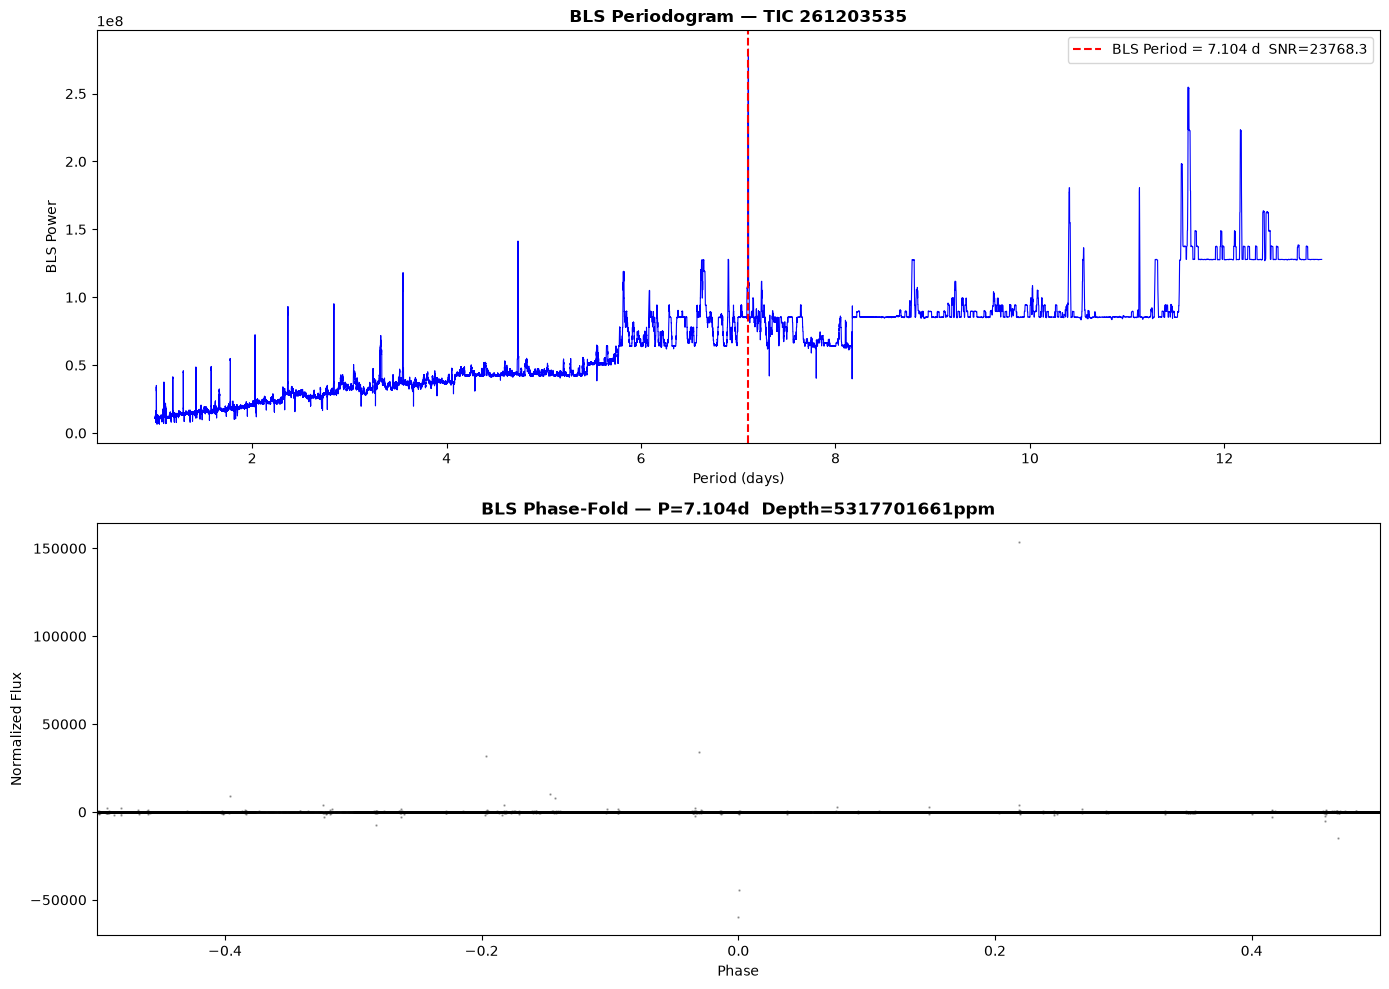

BLS vs TLS comparison plot saved!


In [7]:
# Re-run on best star to get periodogram objects
best_tic = results_df.sort_values('snr', ascending=False).iloc[0]['tic_id']
best_tic = str(best_tic).replace('.0','')
df_best  = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{best_tic}.csv'))
time_b   = df_best['time'].values
flux_b   = df_best['flux'].values
mask_b   = np.isfinite(time_b) & np.isfinite(flux_b)
time_b, flux_b = time_b[mask_b], flux_b[mask_b]

bls_b = run_bls(time_b, flux_b)
tls_b = run_tls(time_b, flux_b) if TLS_OK else None

n_panels = 3 if tls_b else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(14, 5*n_panels))
if n_panels == 1:
    axes = [axes]

# BLS Periodogram
pgram = bls_b['periodogram']
axes[0].plot(pgram.period.value, pgram.power, 'b-', lw=0.8)
axes[0].axvline(bls_b['best_period'], color='red', linestyle='--',
                label=f"BLS Period = {bls_b['best_period']:.3f} d  SNR={bls_b['snr']:.1f}")
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('BLS Power')
axes[0].set_title(f'BLS Periodogram — TIC {best_tic}', fontweight='bold')
axes[0].legend()

# Phase fold BLS
period_b = bls_b['best_period']
t0_b     = bls_b['transit_time']
phase_b  = ((time_b - t0_b) % period_b) / period_b
phase_b[phase_b > 0.5] -= 1.0
sidx     = np.argsort(phase_b)
axes[1].plot(phase_b[sidx], flux_b[sidx], 'k.', markersize=1.5, alpha=0.3)
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title(
    f'BLS Phase-Fold — P={period_b:.3f}d  Depth={bls_b["best_depth"]*1e6:.0f}ppm',
    fontweight='bold'
)

# TLS result
if tls_b and n_panels == 3:
    r = tls_b['result_obj']
    axes[2].plot(r.periods, r.power, 'g-', lw=0.8)
    axes[2].axvline(tls_b['best_period'], color='red', linestyle='--',
                    label=f"TLS Period={tls_b['best_period']:.3f}d  "
                          f"SDE={tls_b['sde']:.1f}  FAP={tls_b['fap']:.4f}")
    axes[2].set_xlabel('Period (days)')
    axes[2].set_ylabel('TLS Power (SDE)')
    axes[2].set_title('TLS Periodogram', fontweight='bold')
    axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bls_tls_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('BLS vs TLS comparison plot saved!')

---
## ✅ Done!
**What changed vs old notebook 03:**
- Added TLS alongside BLS
- TLS gives FAP, SDE, rp_rs, odd_even_mismatch directly
- Results use TLS values as primary when available
- Both algorithms must agree on period for highest confidence

**Next → 04_feature_extraction.ipynb**